# Exploratory Data Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [3]:
df = pd.read_parquet('../data/all_raman_spectra.parquet')
df.head()

,X,Y,Wave,Intensity,label,group,center,brain,place
0,-10392.915039,-31115.347656,2837.701172,3840.666260,control,3,2900,cerebellum_left,2_1
1,2247.885498,86701.687500,1571.409180,4657.676270,exo,1,1500,cortex,4_2
2,-6609.865234,11719.370117,2477.824219,7965.663574,control,2a,2900,striatum_left,2_3
3,33053.171875,-3075.528320,3112.140625,6354.289551,exo,2b,2900,cortex_left,2_1
4,-22586.171875,-24810.199219,1857.291016,5895.810059,exo,3,1500,cerebellum_right,3_2


## Преобразование в "широкую таблицу"

- широкий df где строка = один спектр, колонки = значения Wave, последняя колонка - `label`.

In [4]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

def transform_spectra(df: pd.DataFrame) -> pd.DataFrame:
    df = df[['X', 'Y', 'Wave', 'Intensity', 'label']].copy()

    # Нормализация по каждому спектру
    df['Intensity'] = df.groupby(['X', 'Y'])['Intensity'].transform(lambda x: x / x.mean())

    # Общая сетка Wave
    wave_min = df['Wave'].min()
    wave_max = df['Wave'].max()
    n_points = int(df.groupby(['X', 'Y'])['Wave'].count().median())
    common_grid = np.linspace(wave_min, wave_max, n_points)

    # Интерполяция каждого спектра на общую сетку
    rows = []
    for (x, y), group in df.groupby(['X', 'Y']):
        group = group.sort_values('Wave')
        
        # Сохраняем label ДО группировки по Wave
        label = group['label'].iloc[0]
        
        # Убираем дубликаты Wave
        group = group.groupby('Wave', as_index=False)['Intensity'].mean()
        
        interp_fn = interp1d(group['Wave'], group['Intensity'],
                             kind='linear', bounds_error=False, fill_value='extrapolate')
        intensities = interp_fn(common_grid)
        rows.append(list(intensities) + [label])

    result = pd.DataFrame(rows, columns=list(common_grid) + ['label'])
    return result


df = transform_spectra(df)

KeyboardInterrupt: 

In [1]:
df.head()


NameError: name 'df' is not defined

In [6]:
X = df.drop('label', axis=1).values
y = df['label'].values


raman_shift = df.drop(columns=["label"]).columns.astype(float)

/home/noda/Projects/raman-spectroscopy/.venv/lib/python3.12/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


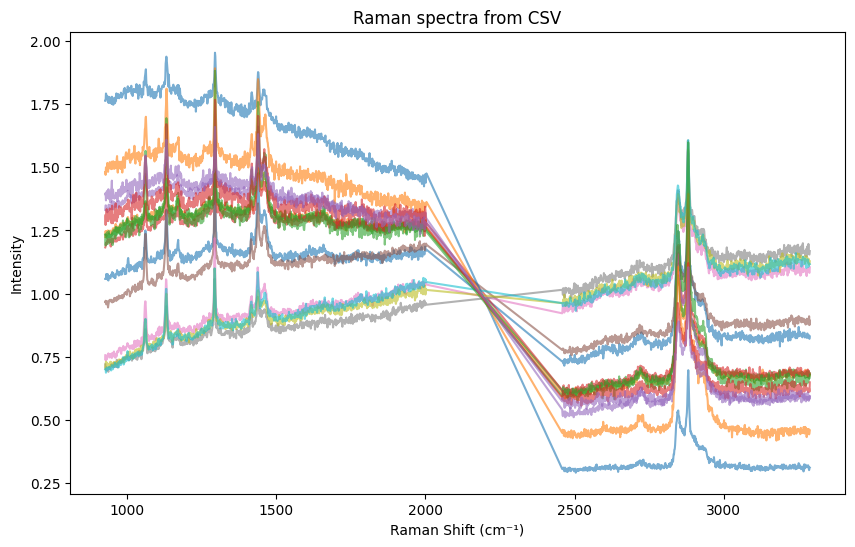

In [23]:
plt.figure(figsize=(10,6))

# control
for i in range(5):
    plt.plot(raman_shift, X[y=='exo'][i], alpha=0.6)

# exo
for i in range(5):
    plt.plot(raman_shift, X[y=='control'][i], alpha=0.6)

for i in range(5):
    plt.plot(raman_shift, X[y=='endo'][i], alpha=.6)

plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity")
plt.title("Raman spectra from CSV")
plt.show()

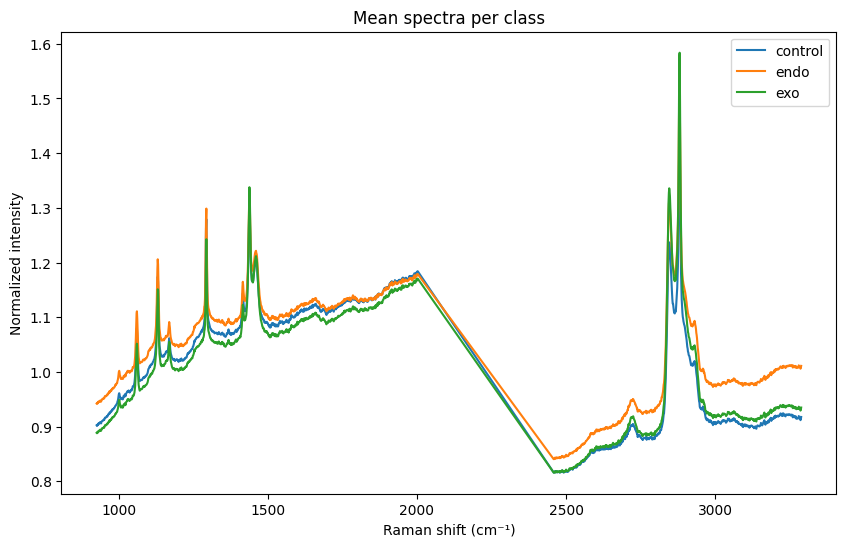

In [24]:
plt.figure(figsize=(10, 6))

for label_name in sorted(df['label'].unique()):
    mask = df['label'] == label_name
    mean_spectrum = df.loc[mask, df.columns != 'label'].mean(axis=0)
    plt.plot(raman_shift, mean_spectrum, label=label_name)

plt.legend()
plt.title("Mean spectra per class")
plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("Normalized intensity")
plt.show()

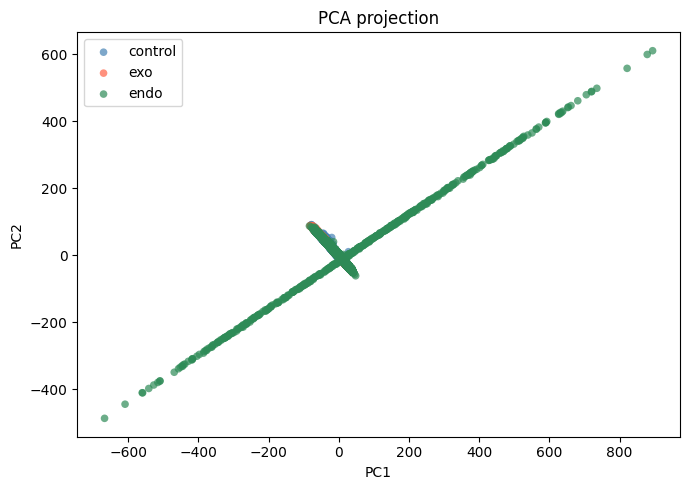

In [ ]:
gfrom sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Подготовка данных
label_col = 'label'
X = df.drop(columns=[label_col]).values
labels = df[label_col].values

# PCA
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=3).fit_transform(X_scaled)

# Цвета и маркеры для каждого класса
palette = {'control': 'steelblue', 'exo': 'tomato', 'endo': 'seagreen'}

plt.figure(figsize=(7, 5))
for label_name, color in palette.items():
    mask = labels == label_name
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=label_name, alpha=0.7, edgecolors='none', s=30)

plt.legend()
plt.title("PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler, normalize
from scipy.signal import savgol_filter

def smooth_spectra(X, window_length=11, polyorder=3):
    X_smooth = np.array([
        savgol_filter(spectrum, window_length, polyorder) 
        for spectrum in X
    ])

    return X_smooth

X = smooth_spectra(X)

X[:10]

array([[1.0548952 , 1.0617638 , 1.0660754 , ..., 0.82703197, 0.8263003 ,
        0.8264378 ],
       [1.2326467 , 1.2318195 , 1.2331853 , ..., 0.6791678 , 0.6782357 ,
        0.6778255 ],
       [1.2344884 , 1.2355864 , 1.2349318 , ..., 0.6766296 , 0.6784876 ,
        0.68251246],
       ...,
       [1.3018131 , 1.3013692 , 1.3013945 , ..., 0.610766  , 0.6090389 ,
        0.60557485],
       [1.1570995 , 1.1535447 , 1.150986  , ..., 0.7191587 , 0.71912116,
        0.7215957 ],
       [1.0781443 , 1.0850402 , 1.0880429 , ..., 0.76171124, 0.7598177 ,
        0.7581805 ]], dtype=float32)

In [27]:
def area_normalization(X):
    return normalize(X, norm="l1")

X = area_normalization(X)

X[:10]

array([[0.00051621, 0.00051957, 0.00052168, ..., 0.00040471, 0.00040435,
        0.00040442],
       [0.00059599, 0.00059559, 0.00059625, ..., 0.00032838, 0.00032793,
        0.00032773],
       [0.0005967 , 0.00059723, 0.00059692, ..., 0.00032706, 0.00032795,
        0.0003299 ],
       ...,
       [0.00062756, 0.00062735, 0.00062736, ..., 0.00029443, 0.0002936 ,
        0.00029193],
       [0.00056093, 0.00055921, 0.00055797, ..., 0.00034863, 0.00034861,
        0.00034981],
       [0.00052385, 0.0005272 , 0.00052866, ..., 0.0003701 , 0.00036918,
        0.00036838]], dtype=float32)

In [28]:
def add_first_derivative(X):
    derivative = np.gradient(X, axis=1)
    # second_derivative = np.gradient(derivative, axis=1) # - ВТОРАЯ ПРОИЗВОДНАЯ.
    return np.hstack([X, derivative]) 

X = add_first_derivative(X)

X[:10]

array([[ 5.1621319e-04,  5.1957433e-04,  5.2168424e-04, ...,
        -5.0125527e-07, -1.4538819e-07,  6.7258952e-08],
       [ 5.9598626e-04,  5.9558632e-04,  5.9624668e-04, ...,
        -5.1359530e-07, -3.2450771e-07, -1.9834260e-07],
       [ 5.9670111e-04,  5.9723185e-04,  5.9691549e-04, ...,
         4.9042865e-07,  1.4217658e-06,  1.9454747e-06],
       ...,
       [ 6.2756380e-04,  6.2734983e-04,  6.2736199e-04, ...,
        -5.4090924e-07, -1.2512464e-06, -1.6699196e-06],
       [ 5.6092918e-04,  5.5920589e-04,  5.5796548e-04, ...,
        -4.3281761e-07,  5.9069134e-07,  1.1995726e-06],
       [ 5.2384671e-04,  5.2719726e-04,  5.2865618e-04, ...,
        -9.2614209e-07, -8.5774809e-07, -7.9549500e-07]], dtype=float32)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'control': np.int64(0), 'endo': np.int64(1), 'exo': np.int64(2)}


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)),
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=1
        )
     )
])

In [32]:
# param_grid = {
#     "xgb__n_estimators": [100, 300],
#     "xgb__max_depth": [3, 5, 7],
#     "xgb__learning_rate": [0.01, 0.1, 0.3],
#     "xgb__subsample": [0.8, 1.0],
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=cv,
#     scoring="roc_auc",
#     n_jobs=1
# )

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=50)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=1, num_class=3, ...))])

In [33]:
from sklearn.metrics import f1_score

In [34]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(f'F1 (macro)  = {f1_score(y_test, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

F1 (macro)  = 0.7882

              precision    recall  f1-score   support

     control       0.79      0.77      0.78      4200
        endo       0.81      0.78      0.79      3885
         exo       0.77      0.82      0.79      4410

    accuracy                           0.79     12495
   macro avg       0.79      0.79      0.79     12495
weighted avg       0.79      0.79      0.79     12495

